In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
trans = pd.read_csv('/data/raw/transactions.csv')

In [ ]:
trans.columns

Index(['datetime', 'from_institution', 'to_institution', 'amount',
       'transaction_type'],
      dtype='object')

In [ ]:
trans = trans.sort_values(by='datetime')
trans.head()

,datetime,from_institution,to_institution,amount,transaction_type
35593,2016-01-01 00:04:00,INST0275,INST0500,4.91,collateral
36343,2016-01-01 00:05:00,INST0307,INST0144,27.51,settlement
35764,2016-01-01 00:06:00,INST0418,INST0275,0.93,payment
36363,2016-01-01 00:10:00,INST0103,INST0170,5.02,repo
36258,2016-01-01 00:15:00,INST0311,INST0107,34.86,repo


In [ ]:
trans.tail()

,datetime,from_institution,to_institution,amount,transaction_type
17245,2025-10-10 23:47:00,INST0084,INST0052,21.26,repo
17149,2025-10-10 23:49:00,INST0358,INST0404,126.19,payment
17581,2025-10-10 23:52:00,INST0499,INST0492,7.65,payment
17808,2025-10-10 23:58:00,INST0350,INST0455,9.35,settlement
17385,2025-10-10 23:59:00,INST0095,INST0127,2.82,derivative


In [ ]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50859 entries, 35593 to 17385
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          50859 non-null  object 
 1   from_institution  50859 non-null  object 
 2   to_institution    50859 non-null  object 
 3   amount            50859 non-null  float64
 4   transaction_type  50859 non-null  object 
dtypes: float64(1), object(4)
memory usage: 4.3+ MB


In [ ]:
trans.describe()

,amount
count,50859.000000
mean,22.750245
std,68.847181
min,0.010000
25%,2.690000
50%,7.360000
75%,20.215000
max,4064.960000


In [ ]:
trans.isna().sum()

,0
datetime,0
from_institution,0
to_institution,0
amount,0
transaction_type,0


In [ ]:
trans['datetime']

,datetime
35593,2016-01-01 00:04:00
36343,2016-01-01 00:05:00
35764,2016-01-01 00:06:00
36363,2016-01-01 00:10:00
36258,2016-01-01 00:15:00
...,...
17245,2025-10-10 23:47:00
17149,2025-10-10 23:49:00
17581,2025-10-10 23:52:00
17808,2025-10-10 23:58:00


In [ ]:
import networkx as nx

G = nx.DiGraph()  # Directed graph

for _, row in trans.iterrows():
    G.add_edge(row['from_institution'], row['to_institution'], weight=row['amount'])


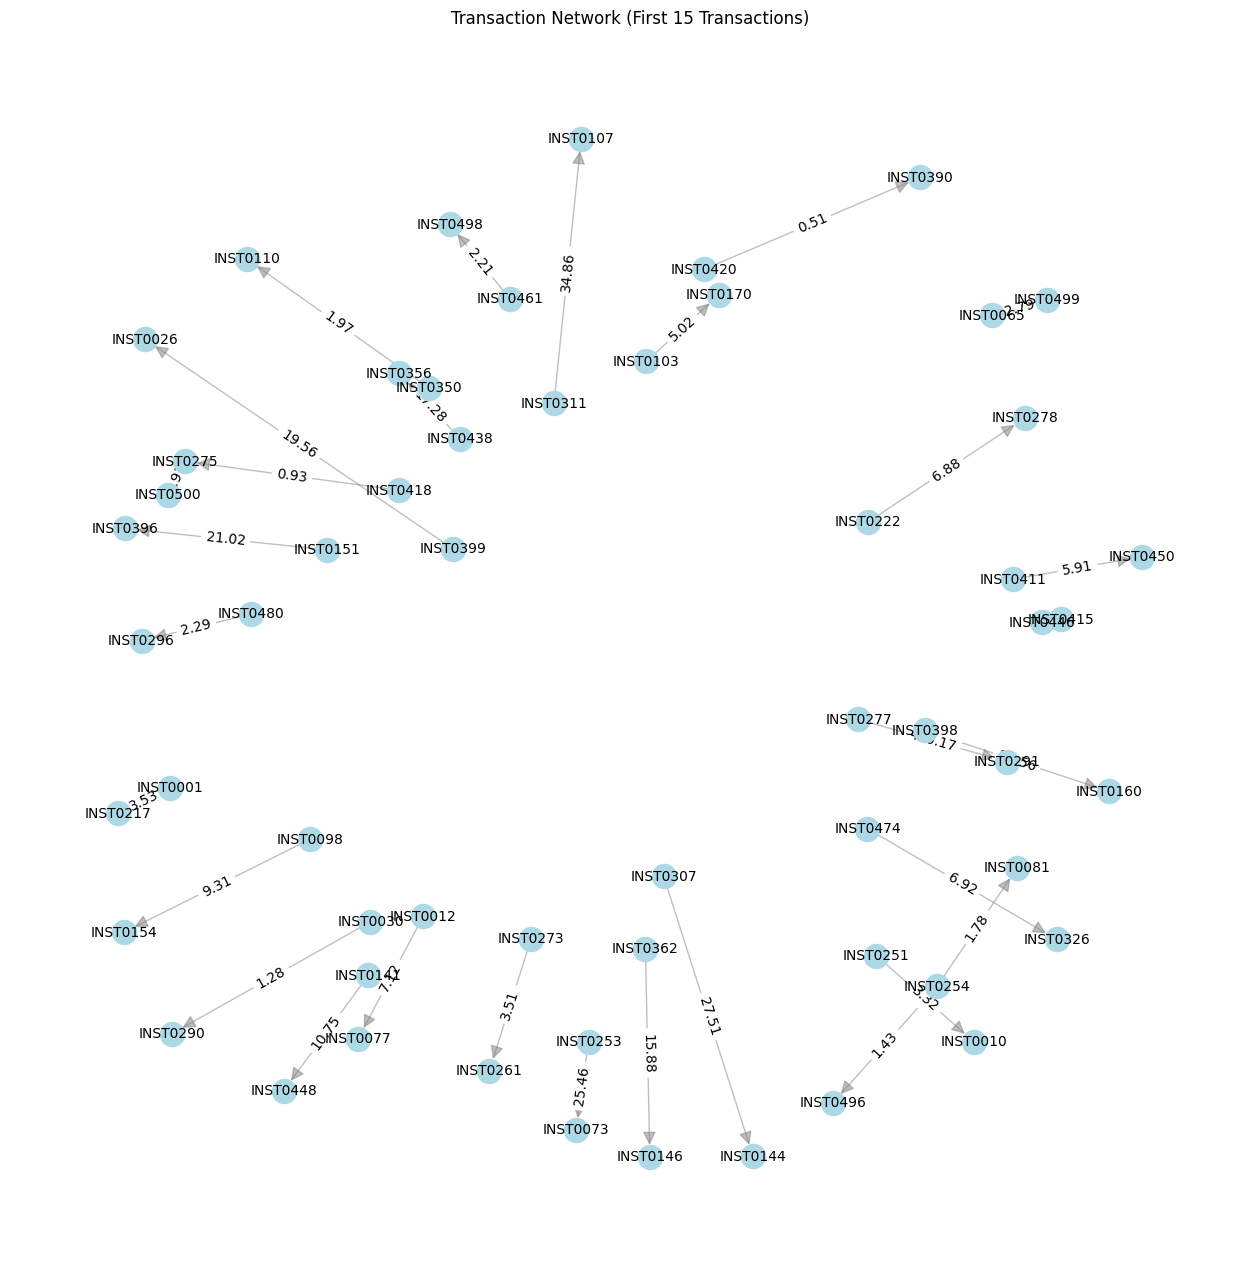

In [ ]:
filtered_transactions_df = trans.head(30)

# Step 2: Create the transaction network for the filtered transactions
G = nx.DiGraph()  # Directed graph

# Adding edges to the graph (only for the first 15 transactions)
for _, row in filtered_transactions_df.iterrows():
    G.add_edge(row['from_institution'], row['to_institution'], weight=row['amount'])

# Step 3: Visualize the Network
plt.figure(figsize=(16, 16))

# Define positions using the spring layout
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightblue')
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, width=1.0, alpha=0.5, edge_color='gray')

# Draw node labels (institutions)
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

# Draw edge labels (transaction amounts)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# Display the plot
plt.title("Transaction Network (First 15 Transactions)")
plt.axis('off')  # Disable the axis
plt.show()

In [ ]:
# Distribution of transaction types
transaction_type_counts = trans['transaction_type'].value_counts()
print(transaction_type_counts)


transaction_type
payment       10328
repo          10313
settlement    10128
derivative    10049
collateral    10041
Name: count, dtype: int64


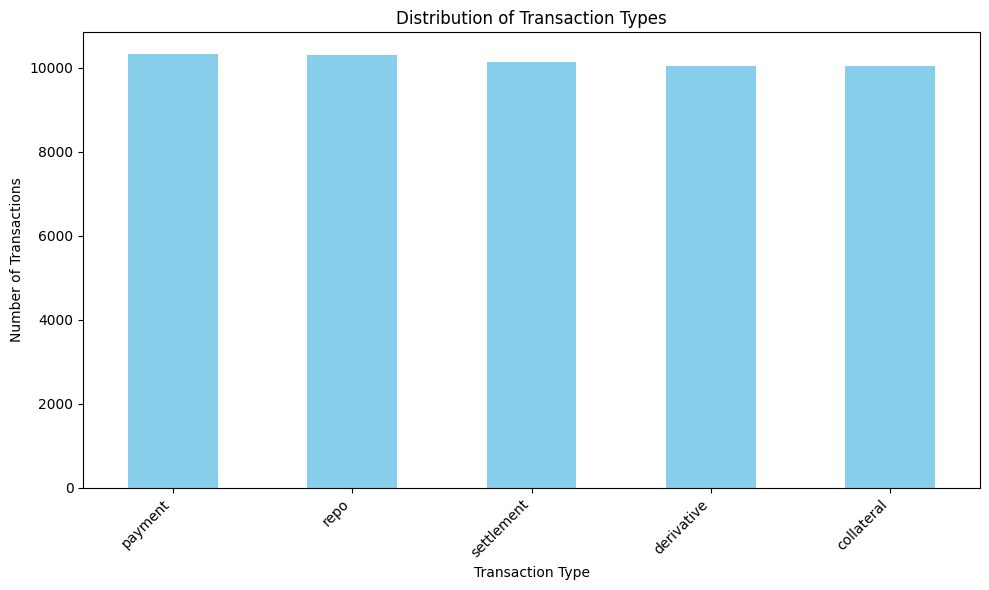

In [ ]:
plt.figure(figsize=(10, 6))
transaction_type_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Convert 'datetime' column to datetime format (if it's not already)
trans['datetime'] = pd.to_datetime(trans['datetime'])

# Group by month and count the number of transactions
monthly_transactions = trans.groupby(trans['datetime'].dt.to_period('M')).size()
print(monthly_transactions)


datetime
2016-01     801
2016-03    1010
2016-04    1159
2016-11    1124
2016-12     967
2017-01     823
2017-02     908
2017-05    1130
2017-07    1156
2017-08     972
2018-01    1124
2018-03    1171
2018-04     953
2018-05    1088
2018-07    1001
2018-09    1142
2018-11    1040
2019-07    1053
2019-08     853
2019-09    1163
2019-12    1022
2020-05    1152
2020-06     830
2020-09    1182
2021-04    1133
2021-09    1085
2021-10    1122
2022-02     962
2022-04     926
2022-08     822
2022-10     973
2023-01    1129
2023-02     817
2023-04     983
2023-06     803
2023-09    1123
2024-05    1068
2024-06    1044
2024-07     916
2024-09     990
2024-10     868
2024-11    1048
2024-12    1187
2025-01    1023
2025-03    1195
2025-04     943
2025-06     919
2025-08     925
2025-09    1047
2025-10     984
Freq: M, dtype: int64


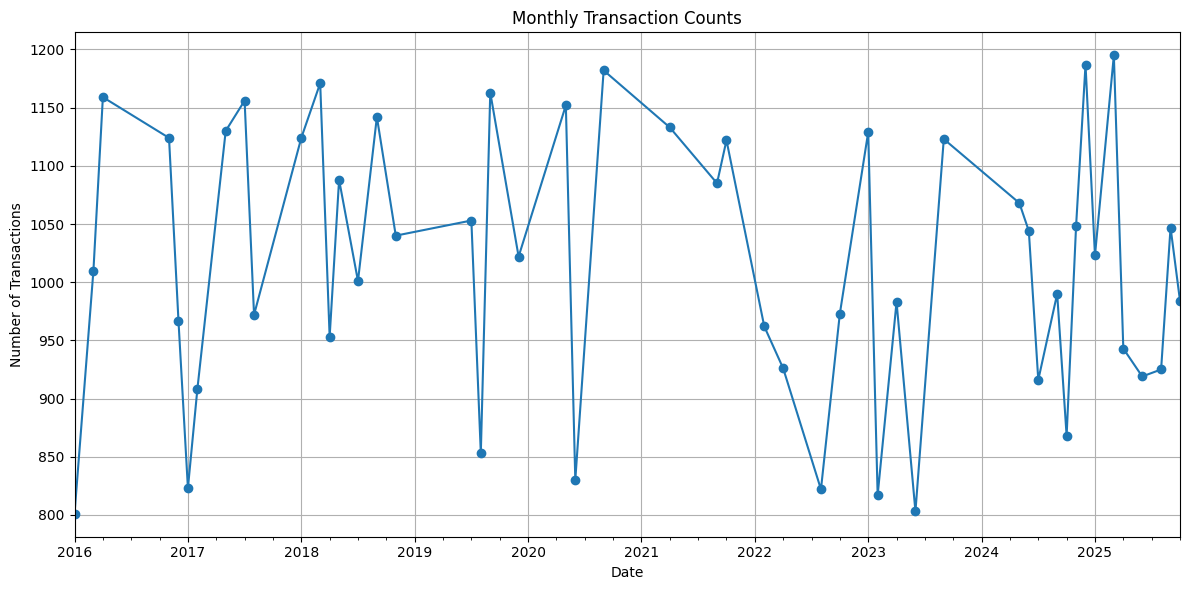

In [ ]:
plt.figure(figsize=(12, 6))
monthly_transactions.plot(kind='line', marker='o', linestyle='-')
plt.title('Monthly Transaction Counts')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Convert 'datetime' column to datetime format (if it's not already)
trans['datetime'] = pd.to_datetime(trans['datetime'])

# Group by hour and count the number of transactions
hourly_transactions = trans.groupby(trans['datetime'].dt.hour).size()

# Print hourly transactions count
print(hourly_transactions)

datetime
0     2148
1     2093
2     2077
3     2207
4     2112
5     2155
6     2148
7     2160
8     2133
9     2103
10    2085
11    2152
12    2108
13    2129
14    2065
15    2186
16    2053
17    2105
18    2164
19    2157
20    2165
21    1998
22    2039
23    2117
dtype: int64


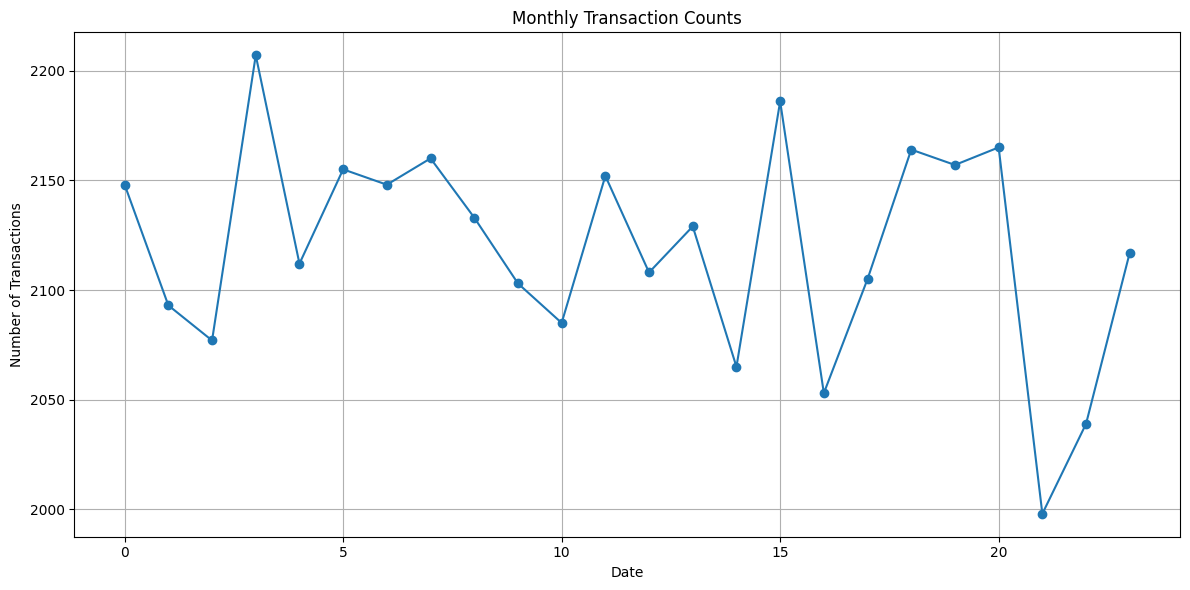

In [ ]:
plt.figure(figsize=(12, 6))
hourly_transactions.plot(kind='line', marker='o', linestyle='-')
plt.title('Monthly Transaction Counts')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Convert 'datetime' column to datetime format (if it's not already)
trans['datetime'] = pd.to_datetime(trans['datetime'])

# Group by year and count the number of transactions
yearly_transactions = trans.groupby(trans['datetime'].dt.year).size()

# Print yearly transactions count
print(yearly_transactions)

datetime
2016    5061
2017    4989
2018    7519
2019    4091
2020    3164
2021    3340
2022    3683
2023    4855
2024    7121
2025    7036
dtype: int64


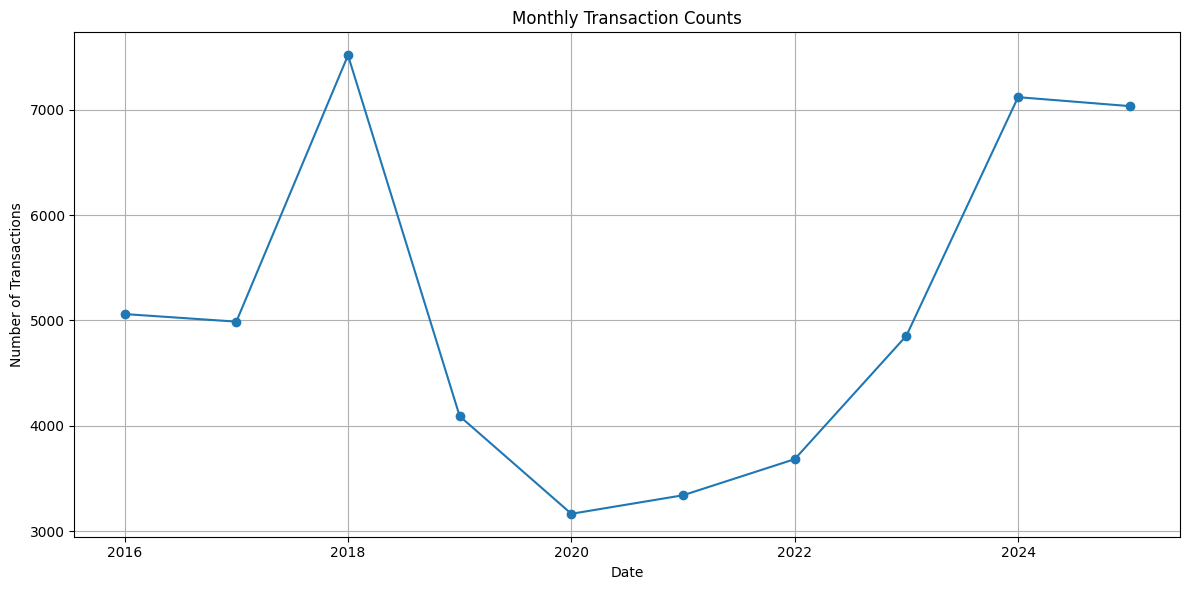

In [ ]:
plt.figure(figsize=(12, 6))
yearly_transactions.plot(kind='line', marker='o', linestyle='-')
plt.title('Monthly Transaction Counts')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Most active senders (from_institution)
top_senders = trans.groupby('from_institution')['amount'].sum().sort_values(ascending=False)
print(top_senders.head())

# Most active receivers (to_institution)
top_receivers = trans.groupby('to_institution')['amount'].sum().sort_values(ascending=False)
print(top_receivers.head())


from_institution
INST0469    6871.64
INST0141    6010.60
INST0352    5484.63
INST0475    5422.93
INST0017    5158.35
Name: amount, dtype: float64
to_institution
INST0500    7251.99
INST0468    5847.55
INST0250    4744.50
INST0418    4598.18
INST0419    4486.01
Name: amount, dtype: float64


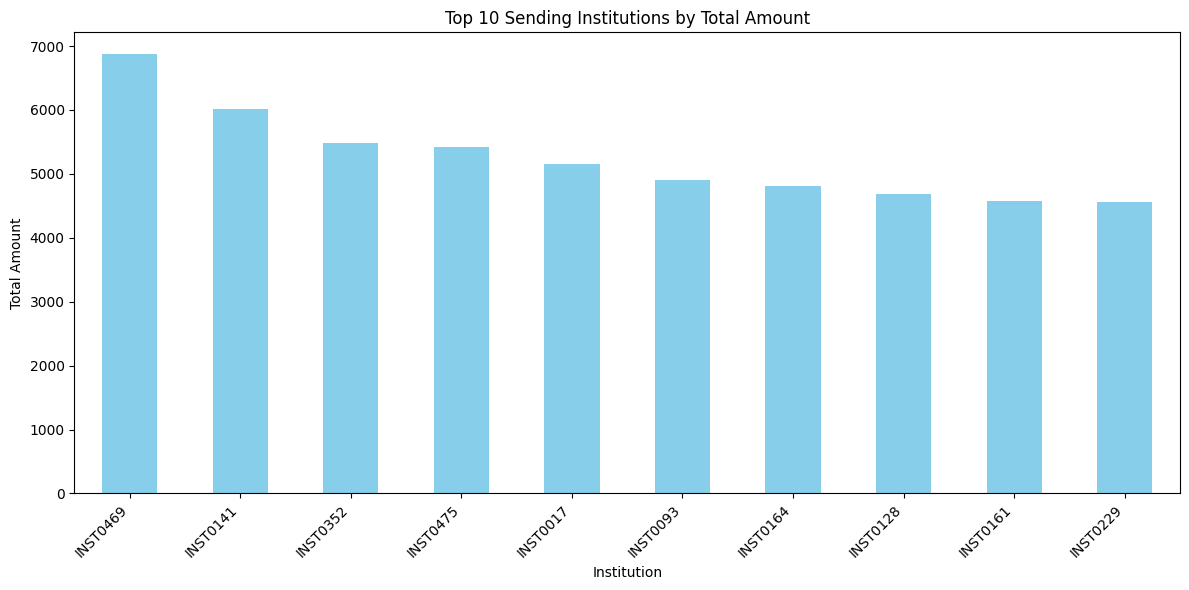

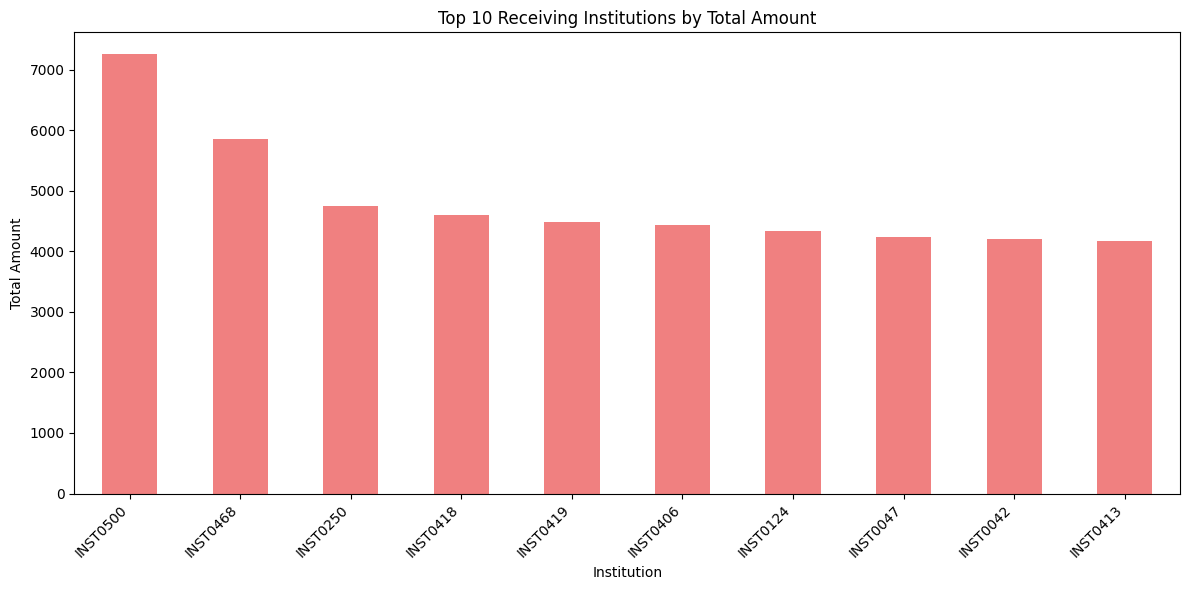

In [ ]:
plt.figure(figsize=(12, 6))
top_senders.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Sending Institutions by Total Amount')
plt.xlabel('Institution')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
top_receivers.head(10).plot(kind='bar', color='lightcoral')
plt.title('Top 10 Receiving Institutions by Total Amount')
plt.xlabel('Institution')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Create a new variable to categorize transaction amounts with types
trans['transaction_type_amount'] = trans['transaction_type'] + '_' + (trans['amount'] > 100).astype(str)


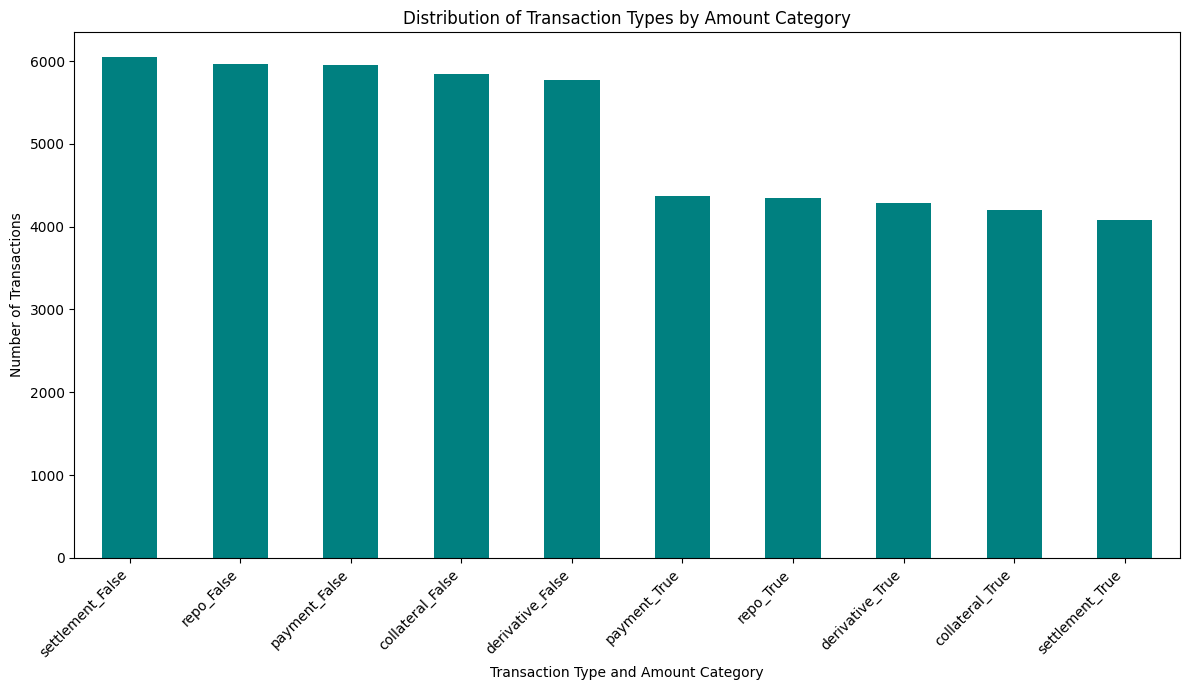

In [ ]:
transaction_type_amount_counts = trans['transaction_type_amount'].value_counts()

plt.figure(figsize=(12, 7))
transaction_type_amount_counts.plot(kind='bar', color='teal')
plt.title('Distribution of Transaction Types by Amount Category')
plt.xlabel('Transaction Type and Amount Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()